In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model8_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model8_0)
describe(model8_0)

MACs: 5.37 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 16,

Loading checkpoint from model_weights/model8_0.pt
Starting
Epoch 1/60: Train loss = 1.1088, Train accuracy = 0.6021, Test loss = 1.0739, Test accuracy = 0.6249
Epoch 2/60: Train loss = 0.8418, Train accuracy = 0.7045, Test loss = 0.8242, Test accuracy = 0.7108
Epoch 3/60: Train loss = 0.7850, Train accuracy = 0.7274, Test loss = 0.7982, Test accuracy = 0.7239
Epoch 4/60: Train loss = 0.8422, Train accuracy = 0.7093, Test loss = 0.8451, Test accuracy = 0.7175
Epoch 5/60: Train loss = 0.6615, Train accuracy = 0.7671, Test loss = 0.6896, Test accuracy = 0.7670
Epoch 6/60: Train loss = 0.6424, Train accuracy = 0.7779, Test loss = 0.6611, Test accuracy = 0.7772
Epoch 7/60: Train loss = 0.6375, Train accuracy = 0.7762, Test loss = 0.6818, Test accuracy = 0.7682
Epoch 8/60: Train loss = 0.5721, Train accuracy = 0.8000, Test loss = 0.5920, Test accuracy = 0.8006
Epoch 9/60: Train loss = 0.5249, Train accuracy = 0.8185, Test loss = 0.5635, Test accuracy = 0.8091
Epoch 10/60: Train loss = 0.5992

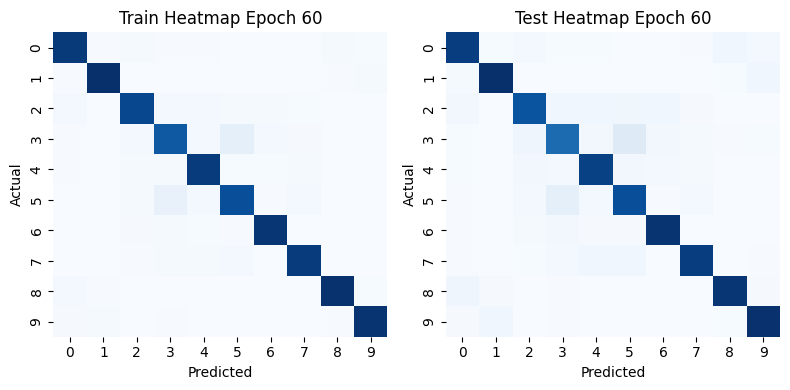

<Figure size 1200x600 with 0 Axes>

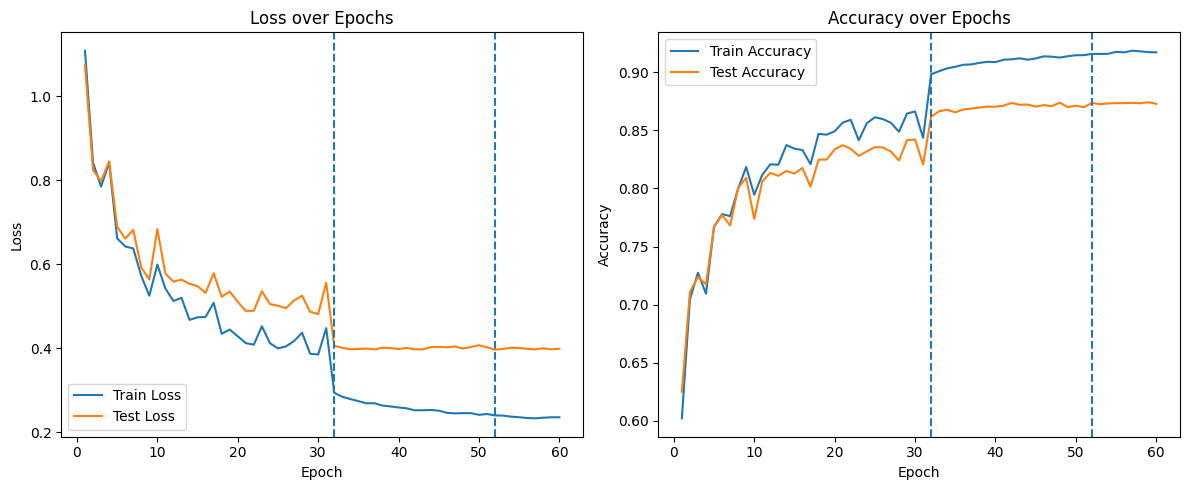

In [6]:
trainf32(model8_0,"model_weights/model8_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model8_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model8_1)
describe(model8_1)

MACs: 5.37 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 16,

Loading checkpoint from model_weights/model8_1.pt
Starting
Epoch 1/60: Train loss = 1.1264, Train accuracy = 0.6135, Test loss = 1.1238, Test accuracy = 0.6189
Epoch 2/60: Train loss = 0.8293, Train accuracy = 0.7096, Test loss = 0.8203, Test accuracy = 0.7117
Epoch 3/60: Train loss = 0.7368, Train accuracy = 0.7441, Test loss = 0.7576, Test accuracy = 0.7407
Epoch 4/60: Train loss = 0.6787, Train accuracy = 0.7606, Test loss = 0.6996, Test accuracy = 0.7575
Epoch 5/60: Train loss = 0.6403, Train accuracy = 0.7788, Test loss = 0.6744, Test accuracy = 0.7734
Epoch 6/60: Train loss = 0.6130, Train accuracy = 0.7849, Test loss = 0.6210, Test accuracy = 0.7878
Epoch 7/60: Train loss = 0.5920, Train accuracy = 0.7931, Test loss = 0.6166, Test accuracy = 0.7926
Epoch 8/60: Train loss = 0.5855, Train accuracy = 0.7973, Test loss = 0.6191, Test accuracy = 0.7892
Epoch 9/60: Train loss = 0.5490, Train accuracy = 0.8062, Test loss = 0.5831, Test accuracy = 0.8021
Epoch 10/60: Train loss = 0.5072

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 59/60: Train loss = 0.2358, Train accuracy = 0.9182, Test loss = 0.3802, Test accuracy = 0.8801
Epoch 60/60: Train loss = 0.2323, Train accuracy = 0.9178, Test loss = 0.3758, Test accuracy = 0.8836
Training complete.


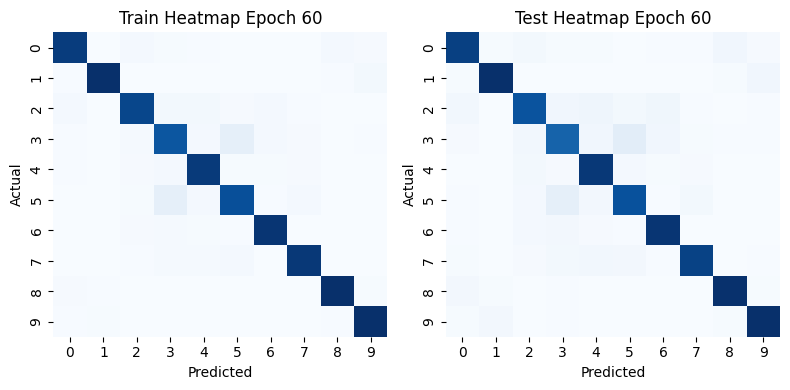

<Figure size 1200x600 with 0 Axes>

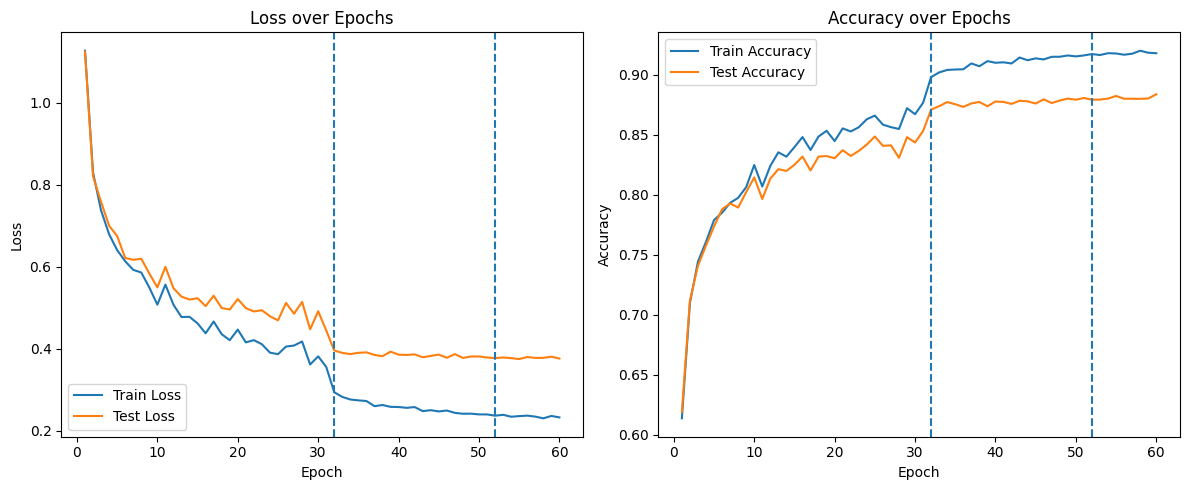

In [8]:
trainf32(model8_1,"model_weights/model8_1.pt",criterion,train_dataset,val_dataset, batch_size=64)